In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

deliveries_df = pd.read_csv('/content/EDA-IPL/data/deliveries.csv')

display(deliveries_df.head())

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [32]:
powerplay_df = deliveries_df[deliveries_df['over'].between(0, 5)].copy()

powerplay_df['bowler_runs'] = powerplay_df['batsman_runs'] + powerplay_df['extra_runs'].fillna(0).apply(lambda x: x if x in [1,2,3,4,5] else 0)

powerplay_runs = powerplay_df.groupby('bowler')['total_runs'].sum().reset_index()
powerplay_runs.rename(columns={'total_runs': 'pp_total_runs'}, inplace=True)

powerplay_legal_balls = powerplay_df[~powerplay_df['extras_type'].isin(['wides', 'noballs'])]
powerplay_legal_balls_count = powerplay_legal_balls.groupby('bowler').size().reset_index(name='pp_legal_balls')

powerplay_stats = pd.merge(powerplay_runs, powerplay_legal_balls_count, on='bowler', how='left')

powerplay_stats['pp_overs'] = powerplay_stats['pp_legal_balls'] / 6

powerplay_stats['pp_economy'] = powerplay_stats['pp_total_runs'] / powerplay_stats['pp_overs']

display(powerplay_stats.sort_values(by='pp_economy').head())

,bowler,pp_total_runs,pp_legal_balls,pp_overs,pp_economy
1,A Badoni,0,1,0.166667,0.000000
364,SM Harwood,7,18,3.000000,2.333333
121,GR Napier,3,6,1.000000,3.000000
49,Ankit Soni,3,6,1.000000,3.000000
30,AJ Finch,3,6,1.000000,3.000000


In [33]:
death_over_df = deliveries_df[deliveries_df['over'].between(15, 19)].copy()

death_over_df['bowler_runs'] = death_over_df['batsman_runs'] + death_over_df['extra_runs'].fillna(0).apply(lambda x: x if x in [1,2,3,4,5] else 0)

death_over_runs = death_over_df.groupby('bowler')['total_runs'].sum().reset_index()
death_over_runs.rename(columns={'total_runs': 'do_total_runs'}, inplace=True)

death_over_legal_balls = death_over_df[~death_over_df['extras_type'].isin(['wides', 'noballs'])]
death_over_legal_balls_count = death_over_legal_balls.groupby('bowler').size().reset_index(name='do_legal_balls')

death_over_stats = pd.merge(death_over_runs, death_over_legal_balls_count, on='bowler', how='left')

death_over_stats['do_overs'] = death_over_stats['do_legal_balls'] / 6

death_over_stats['do_economy'] = death_over_stats['do_total_runs'] / death_over_stats['do_overs']

bowler_economy_stats = pd.merge(powerplay_stats, death_over_stats, on='bowler', how='inner')


qualifying_bowlers = bowler_economy_stats[(bowler_economy_stats['pp_overs'] >= 20) & (bowler_economy_stats['do_overs'] >= 20)]

display(qualifying_bowlers.head())

,bowler,pp_total_runs,pp_legal_balls,pp_overs,pp_economy,do_total_runs,do_legal_balls,do_overs,do_economy
6,A Mishra,174,138,23.000000,7.565217,831,521,86.833333,9.570058
8,A Nehra,1387,1093,182.166667,7.613907,794,527,87.833333,9.039848
10,A Nortje,598,426,71.000000,8.422535,711,422,70.333333,10.109005
11,A Singh,308,264,44.000000,7.000000,272,161,26.833333,10.136646
18,AB Agarkar,295,180,30.000000,9.833333,311,182,30.333333,10.252747


In [34]:
death_over_df = deliveries_df[deliveries_df['over'].between(15, 19)].copy()

death_over_df['bowler_runs'] = death_over_df['batsman_runs'] + death_over_df['extra_runs'].fillna(0).apply(lambda x: x if x in [1,2,3,4,5] else 0)

death_over_runs = death_over_df.groupby('bowler')['total_runs'].sum().reset_index()
death_over_runs.rename(columns={'total_runs': 'do_total_runs'}, inplace=True)

death_over_legal_balls = death_over_df[~death_over_df['extras_type'].isin(['wides', 'noballs'])]
death_over_legal_balls_count = death_over_legal_balls.groupby('bowler').size().reset_index(name='do_legal_balls')

death_over_stats = pd.merge(death_over_runs, death_over_legal_balls_count, on='bowler', how='left')

death_over_stats['do_overs'] = death_over_stats['do_legal_balls'] / 6

death_over_stats['do_economy'] = death_over_stats['do_total_runs'] / death_over_stats['do_overs']

display(death_over_stats.sort_values(by='do_economy').head())

,bowler,do_total_runs,do_legal_balls,do_overs,do_economy
21,AC Gilchrist,0,1,0.166667,0.000000
106,DJ Muthuswami,1,6,1.000000,1.000000
359,SE Rutherford,2,5,0.833333,2.400000
345,S Rana,2,4,0.666667,3.000000
247,MP Yadav,4,7,1.166667,3.428571


In [35]:
bowler_economy_stats = pd.merge(powerplay_stats, death_over_stats, on='bowler', how='inner')


qualifying_bowlers = bowler_economy_stats[(bowler_economy_stats['pp_overs'] >= 20) & (bowler_economy_stats['do_overs'] >= 20)]

display(qualifying_bowlers.head())


print("\nTop 10 most economical bowlers in Powerplay (min 20 PP overs & 20 DO overs):")
display(qualifying_bowlers.sort_values(by='pp_economy').head(10))

,bowler,pp_total_runs,pp_legal_balls,pp_overs,pp_economy,do_total_runs,do_legal_balls,do_overs,do_economy
6,A Mishra,174,138,23.000000,7.565217,831,521,86.833333,9.570058
8,A Nehra,1387,1093,182.166667,7.613907,794,527,87.833333,9.039848
10,A Nortje,598,426,71.000000,8.422535,711,422,70.333333,10.109005
11,A Singh,308,264,44.000000,7.000000,272,161,26.833333,10.136646
18,AB Agarkar,295,180,30.000000,9.833333,311,182,30.333333,10.252747



Top 10 most economical bowlers in Powerplay (min 20 PP overs & 20 DO overs):


,bowler,pp_total_runs,pp_legal_balls,pp_overs,pp_economy,do_total_runs,do_legal_balls,do_overs,do_economy
139,JC Archer,393,396,66.000000,5.954545,605,371,61.833333,9.784367
105,DW Steyn,1229,1140,190.000000,6.468421,895,634,105.666667,8.470032
203,M Muralitharan,161,148,24.666667,6.527027,380,275,45.833333,8.290909
321,SL Malinga,1210,1111,185.166667,6.534653,1526,1117,186.166667,8.196956
56,B Kumar,2359,2153,358.833333,6.574083,2126,1353,225.500000,9.427938
99,DP Nannes,377,342,57.000000,6.614035,313,208,34.666667,9.028846
71,C Sakariya,206,186,31.000000,6.645161,237,126,21.000000,11.285714
284,RJ Harris,480,426,71.000000,6.760563,434,274,45.666667,9.503650
147,JJ Bumrah,1191,1054,175.666667,6.779886,1767,1247,207.833333,8.502005
52,Azhar Mahmood,163,144,24.000000,6.791667,339,207,34.500000,9.826087


/tmp/ipykernel_3978/3728620255.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


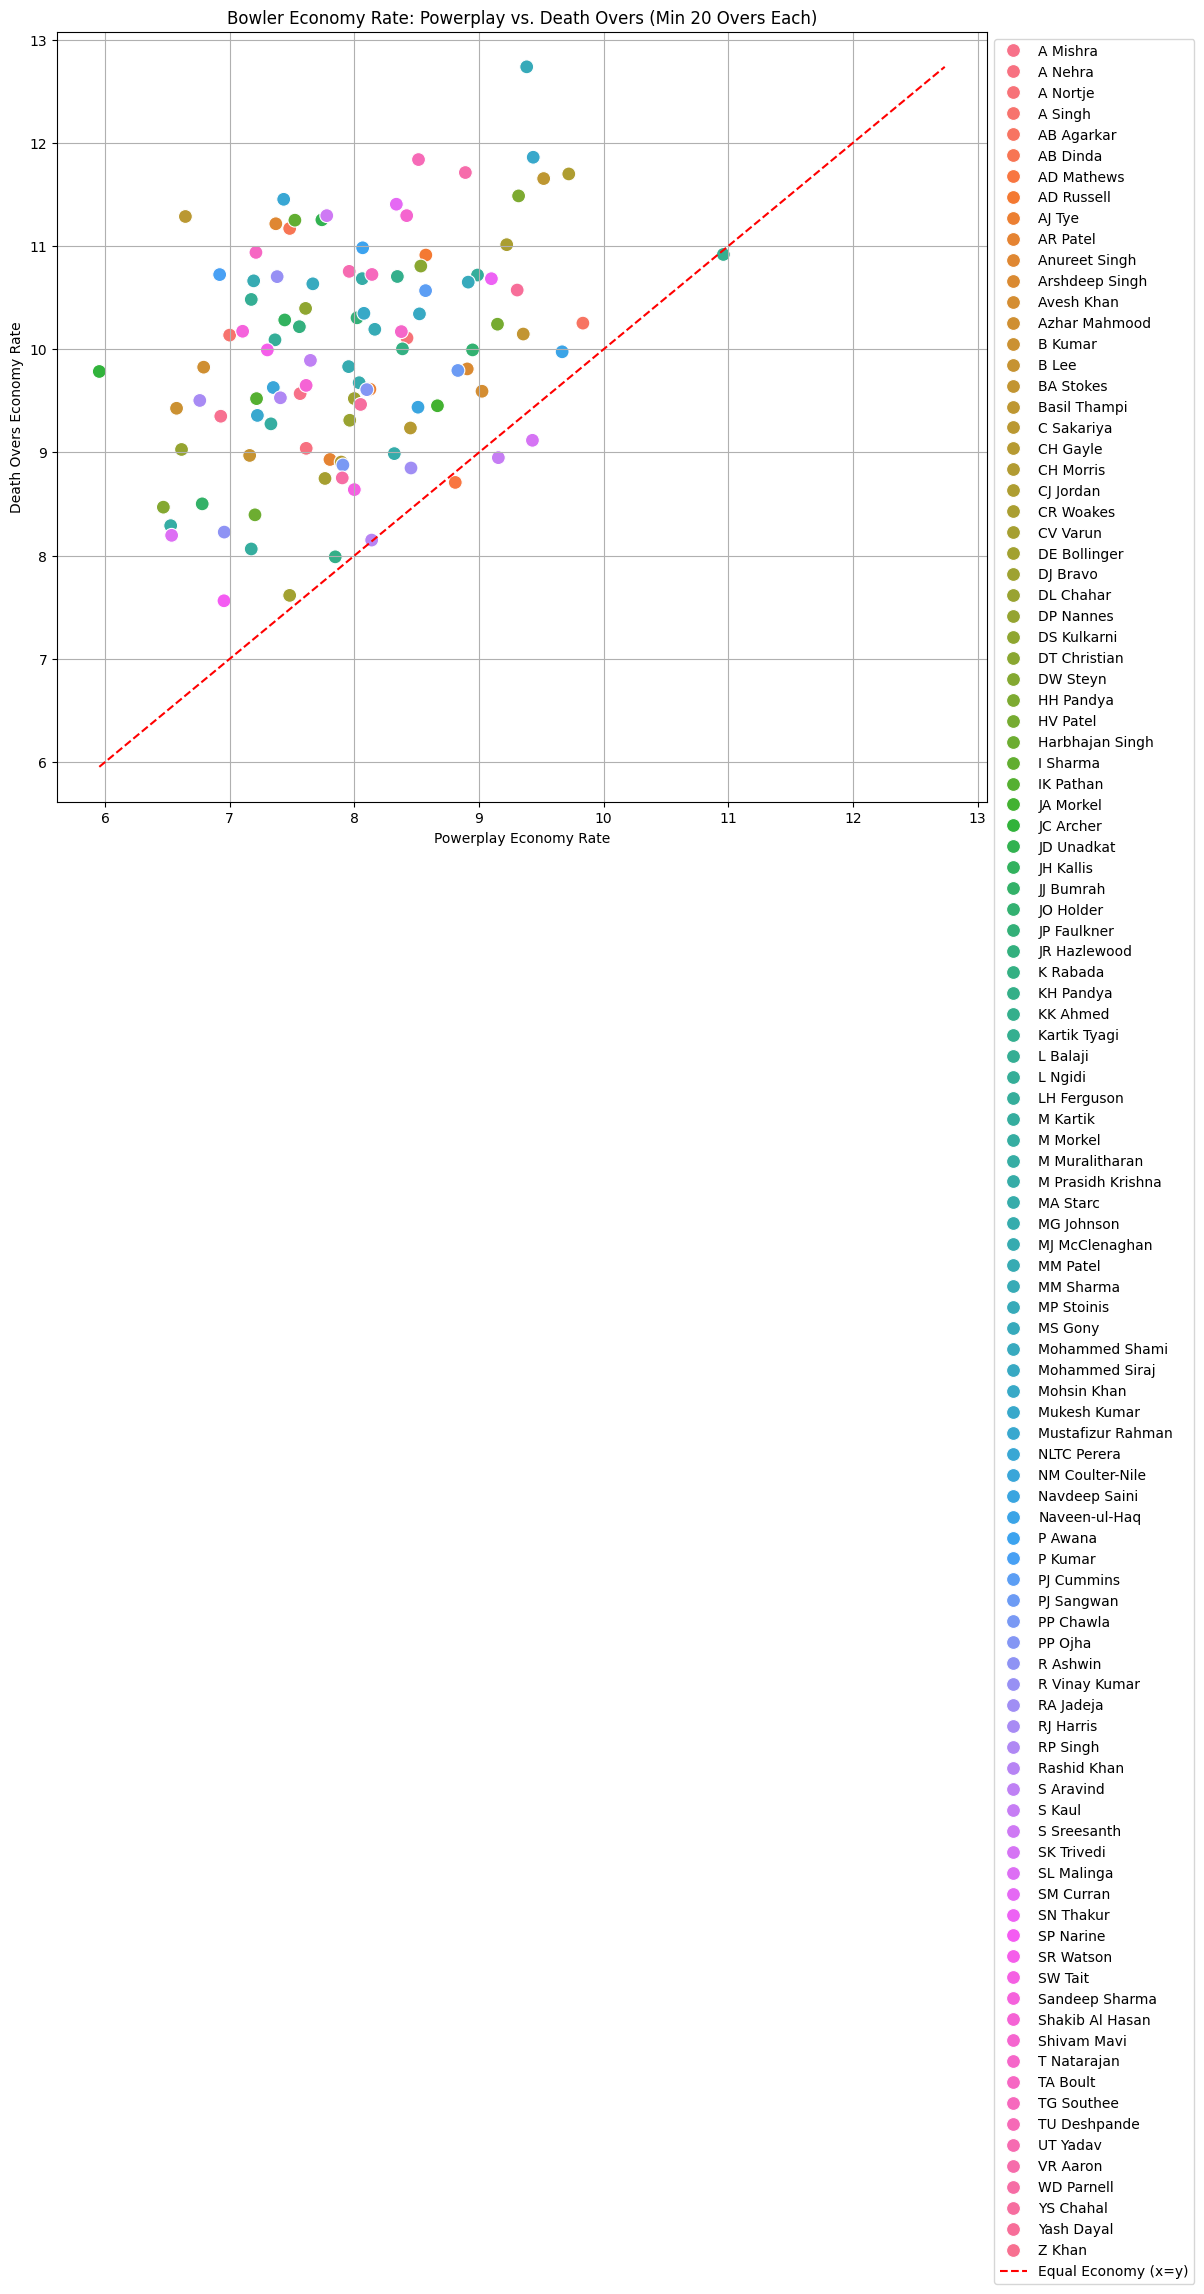

In [36]:
plt.figure(figsize=(12, 10))
sns.scatterplot(data=qualifying_bowlers, x='pp_economy', y='do_economy', hue='bowler', s=100)

max_economy = max(qualifying_bowlers['pp_economy'].max(), qualifying_bowlers['do_economy'].max())
min_economy = min(qualifying_bowlers['pp_economy'].min(), qualifying_bowlers['do_economy'].min())
plt.plot([min_economy, max_economy], [min_economy, max_economy], 'r--', label='Equal Economy (x=y)')

plt.title('Bowler Economy Rate: Powerplay vs. Death Overs (Min 20 Overs Each)')
plt.xlabel('Powerplay Economy Rate')
plt.ylabel('Death Overs Economy Rate')
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()